In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
Using device: cuda


In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

print(f"Train size: {len(train_data)} | Test size: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 351kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.71MB/s]

Train size: 60000 | Test size: 10000


In [3]:
def add_noise(images, noise_factor=0.4):
    """Add Gaussian noise to images"""
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)  # Keep pixel values in [0, 1]
    return noisy

In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder: compresses 784 → 32
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Decoder: reconstructs 32 → 784
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()   # Output in [0, 1]
        )

    def forward(self, x):
        x = x.view(-1, 28*28)        # Flatten
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(-1, 1, 28, 28)   # Reshape back to image

model = DenoisingAutoencoder().to(device)
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:           # Labels not needed
        images = images.to(device)
        noisy_images = add_noise(images).to(device)

        # Forward pass: feed noisy, compare to clean
        outputs = model(noisy_images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {avg_loss:.4f}")

print("\n✅ Training complete!")

Epoch [01/20] | Loss: 0.0653
Epoch [02/20] | Loss: 0.0417
Epoch [03/20] | Loss: 0.0326
Epoch [04/20] | Loss: 0.0296
Epoch [05/20] | Loss: 0.0275
Epoch [06/20] | Loss: 0.0258
Epoch [07/20] | Loss: 0.0244
Epoch [08/20] | Loss: 0.0230
Epoch [09/20] | Loss: 0.0219
Epoch [10/20] | Loss: 0.0212
Epoch [11/20] | Loss: 0.0206
Epoch [12/20] | Loss: 0.0200
Epoch [13/20] | Loss: 0.0196
Epoch [14/20] | Loss: 0.0192
Epoch [15/20] | Loss: 0.0189
Epoch [16/20] | Loss: 0.0186
Epoch [17/20] | Loss: 0.0183
Epoch [18/20] | Loss: 0.0180
Epoch [19/20] | Loss: 0.0177
Epoch [20/20] | Loss: 0.0175

✅ Training complete!


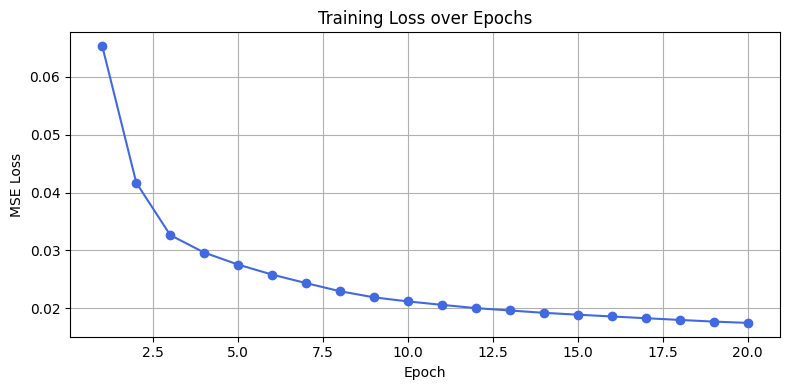

In [6]:
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='royalblue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

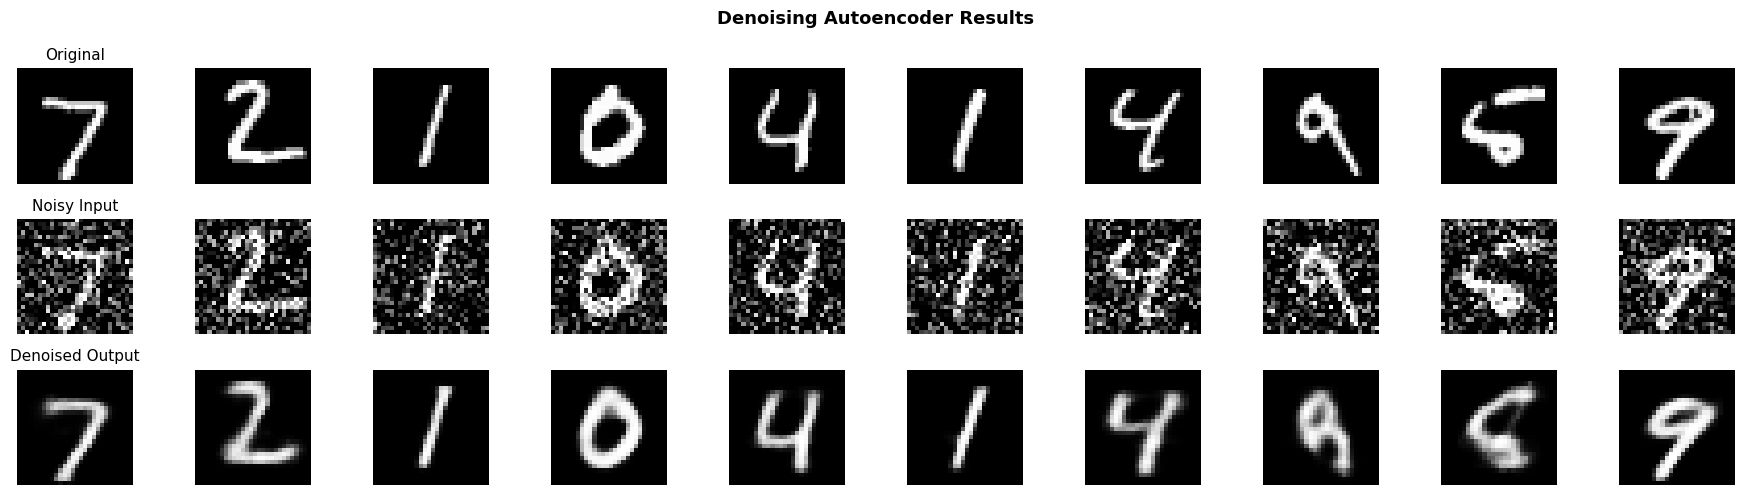

In [7]:
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    noisy_images = add_noise(test_images).to(device)
    reconstructed = model(noisy_images)

# Move to CPU for plotting
test_images   = test_images.cpu()
noisy_images  = noisy_images.cpu()
reconstructed = reconstructed.cpu()

n = 10  # Show 10 examples
fig, axes = plt.subplots(3, n, figsize=(18, 5))

for i in range(n):
    # Row 1: Original
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original", fontsize=11)

    # Row 2: Noisy
    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy Input", fontsize=11)

    # Row 3: Reconstructed (denoised)
    axes[2, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Denoised Output", fontsize=11)

plt.suptitle("Denoising Autoencoder Results", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
torch.save(model.state_dict(), 'denoising_autoencoder.pth')
print("Model saved as denoising_autoencoder.pth")

# Download it to your computer
from google.colab import files
files.download('denoising_autoencoder.pth')

Model saved as denoising_autoencoder.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>